# Lab 3: Oscillator Simulation

Name: Aidan Siddiqi
Date: 9/13/2026
Lab: PHYS 311 Module 3

This notebook simulates the simple harmonic oscillator with both standard Euler and Euler-Cromer, adds phase-space plots and damping, and finishes with a driven oscillator and a resonance curve.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: The Simple Harmonic Oscillator

A mass on a frictionless spring, F = -kx. This has an exact solution, so it is a clean test case before we trust the integrator on anything else.

In [2]:
def simulate_sho(method, dt, n_periods=10, k=1.0, m=1.0, x0=1.0, v0=0.0):
    omega0 = np.sqrt(k / m)
    T = 2 * np.pi / omega0
    t_max = n_periods * T

    x, v = x0, v0
    t = 0.0
    ts, xs, vs = [t], [x], [v]
    Es = [0.5 * k * x**2 + 0.5 * m * v**2]

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x_new = x + v * dt
            v_new = v + a * dt
            x, v = x_new, v_new
        elif method == 'euler-cromer':
            v = v + a * dt
            x = x + v * dt

        t = t + dt
        E = 0.5 * k * x**2 + 0.5 * m * v**2

        ts.append(t)
        xs.append(x)
        vs.append(v)
        Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

Run both methods for 10 periods with dt = 0.05, k = m = 1, x0 = 1, v0 = 0.

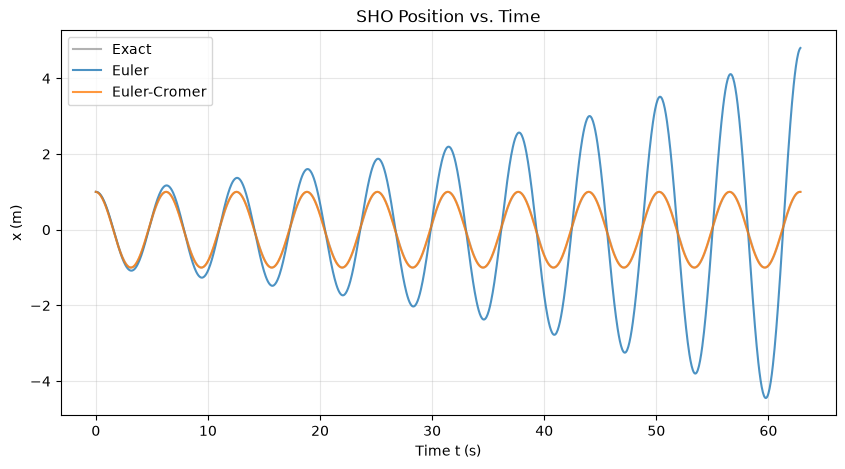

In [3]:
k, m = 1.0, 1.0
x0, v0 = 1.0, 0.0
omega0 = np.sqrt(k / m)
dt = 0.05

t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)

t_fine = np.linspace(0, t_e[-1], 2000)
x_exact = x0 * np.cos(omega0 * t_fine)

plt.figure(figsize=(10, 5))
plt.plot(t_fine, x_exact, color='gray', alpha=0.6, label='Exact')
plt.plot(t_e, x_e, label='Euler', alpha=0.8)
plt.plot(t_ec, x_ec, label='Euler-Cromer', alpha=0.8)
plt.xlabel('Time t (s)')
plt.ylabel('x (m)')
plt.title('SHO Position vs. Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

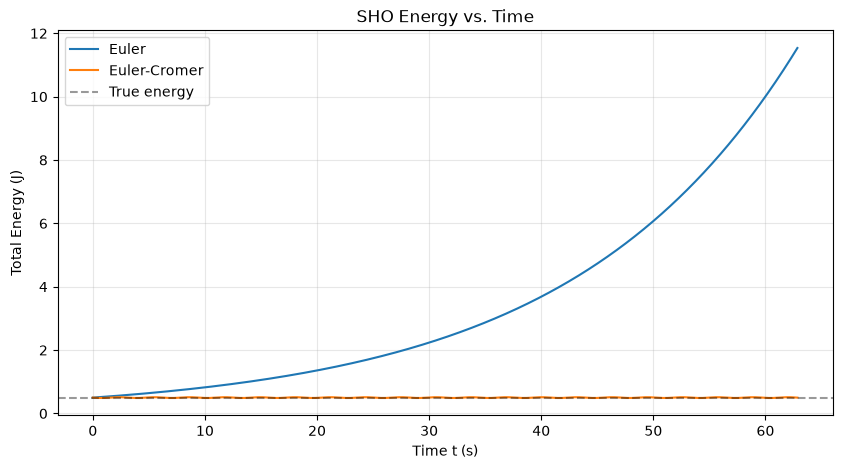

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(t_e, E_e, label='Euler')
plt.plot(t_ec, E_ec, label='Euler-Cromer')
plt.axhline(E_e[0], color='black', linestyle='--', alpha=0.4, label='True energy')
plt.xlabel('Time t (s)')
plt.ylabel('Total Energy (J)')
plt.title('SHO Energy vs. Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:** The Euler amplitude grows with every swing. By 10 periods, it is swinging almost 5 times the starting displacement instead of staying at 1. Its energy climbs, ending more than 20 times the true value. Euler-Cromer does not do this; its amplitude stays around 1 and its energy stays right around the true value the whole time. 

## Part B: Phase Space & Damped Oscillations

### B.1 Phase-space portraits

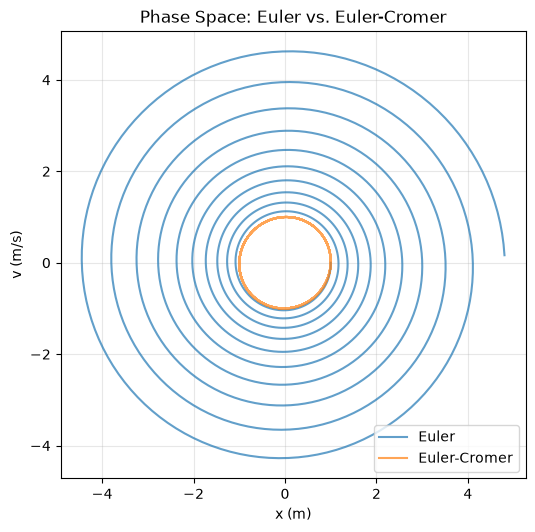

In [5]:
plt.figure(figsize=(6, 6))
plt.plot(x_e, v_e, label='Euler', alpha=0.7)
plt.plot(x_ec, v_ec, label='Euler-Cromer', alpha=0.7)
plt.xlabel('x (m)')
plt.ylabel('v (m/s)')
plt.title('Phase Space: Euler vs. Euler-Cromer')
plt.legend()
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)
plt.show()

Euler spirals outward, where each loop lands a little further out than the last, which is the same energy growth from the plots above showing up as a shape instead of a number. Euler-Cromer traces something very close to a single closed ellipse instead, matching its energy staying flat.

### B.2 Adding Damping

Now add a linear damping force, F = -kx - bv. Using the damping ratio zeta = b / (2*sqrt(km)), we pick b for zeta of about 0.1, 1, and 2 with k = m = 1. We use Euler-Cromer from here on since Part A showed it is the one that can be trusted.

In [6]:
def simulate_damped_sho(b, dt, t_max, k=1.0, m=1.0, x0=1.0, v0=0.0):
    x, v = x0, v0
    t = 0.0
    ts, xs, vs = [t], [x], [v]

    while t < t_max:
        a = -(k / m) * x - (b / m) * v
        v = v + a * dt
        x = x + v * dt
        t = t + dt

        ts.append(t)
        xs.append(x)
        vs.append(v)

    return np.array(ts), np.array(xs), np.array(vs)

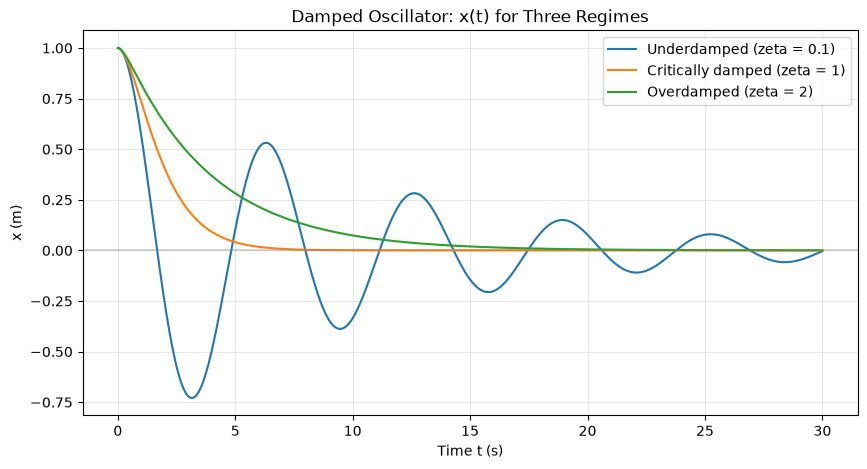

In [7]:
dt_damp = 0.01
t_max_damp = 30.0

zetas = [0.1, 1.0, 2.0]
labels = ['Underdamped (zeta = 0.1)', 'Critically damped (zeta = 1)', 'Overdamped (zeta = 2)']
b_values = [2 * z * np.sqrt(k * m) for z in zetas]

results = []
for b in b_values:
    t_d, x_d, v_d = simulate_damped_sho(b, dt_damp, t_max_damp)
    results.append((t_d, x_d, v_d))

plt.figure(figsize=(10, 5))
for (t_d, x_d, v_d), label in zip(results, labels):
    plt.plot(t_d, x_d, label=label)
plt.axhline(0, color='gray', alpha=0.3)
plt.xlabel('Time t (s)')
plt.ylabel('x (m)')
plt.title('Damped Oscillator: x(t) for Three Regimes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

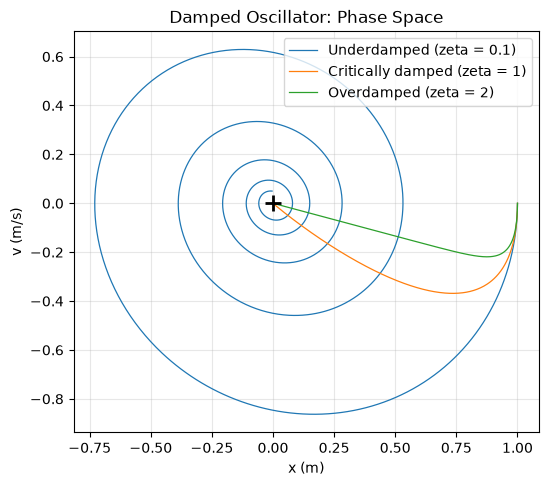

In [8]:
plt.figure(figsize=(6, 6))
for (t_d, x_d, v_d), label in zip(results, labels):
    plt.plot(x_d, v_d, label=label, linewidth=0.9)
plt.plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
plt.xlabel('x (m)')
plt.ylabel('v (m/s)')
plt.title('Damped Oscillator: Phase Space')
plt.legend()
plt.gca().set_aspect('equal')
plt.grid(alpha=0.3)
plt.show()

The underdamped case spirals into the origin, still going around a few times as it shrinks, since there is enough force left to keep it oscillating while it loses energy. The critically damped case cuts almost straight to the origin with barely a hint of a loop. It has just enough damping to kill the oscillation without wasting any time overshooting. The overdamped case does not spiral at all. It just crawls along close to the x-axis toward zero since the damping is strong enough to smother any swing back through the equilibrium.

## Part C: Driven Oscillations & Resonance

Now add a periodic driving force, F = -kx - bv + F0 cos(wd t). We use light damping (b = 0.2, so zeta = 0.1), F0 = 1.0, k = m = 1 so w0 = 1.

In [9]:
def simulate_driven(omega_d, F0, b, dt, t_max, k=1.0, m=1.0, x0=0.0, v0=0.0):
    x, v = x0, v0
    t = 0.0
    ts, xs = [t], [x]

    while t < t_max:
        a = -(k / m) * x - (b / m) * v + (F0 / m) * np.cos(omega_d * t)
        v = v + a * dt
        x = x + v * dt
        t = t + dt

        ts.append(t)
        xs.append(x)

    return np.array(ts), np.array(xs)

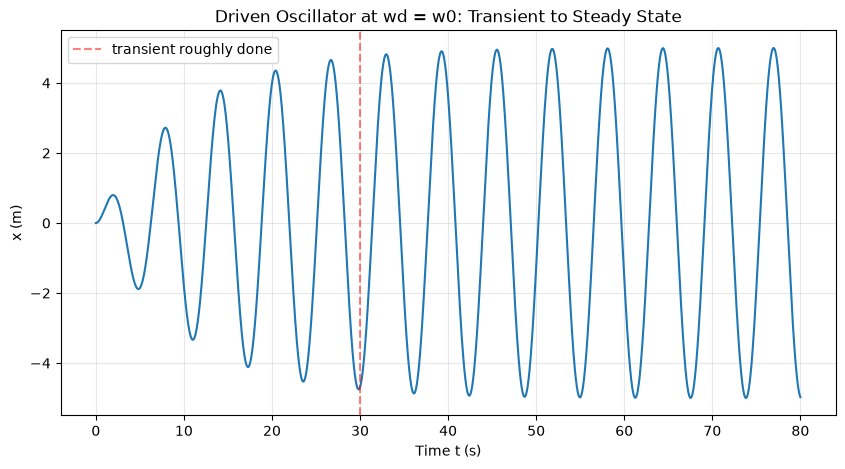

In [10]:
b_drive = 0.2
F0 = 1.0
omega0 = 1.0

t_res, x_res = simulate_driven(omega0, F0, b_drive, dt=0.02, t_max=80.0)

plt.figure(figsize=(10, 5))
plt.plot(t_res, x_res)
plt.axvline(30, color='red', linestyle='--', alpha=0.5, label='transient roughly done')
plt.xlabel('Time t (s)')
plt.ylabel('x (m)')
plt.title('Driven Oscillator at wd = w0: Transient to Steady State')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

For the first several periods the amplitude is still building up as the transient adds onto the steady-state part, then it settles into a steady swing of constant amplitude once the transient has died away, which is the flat, repeating pattern seen in the second half of the plot above.

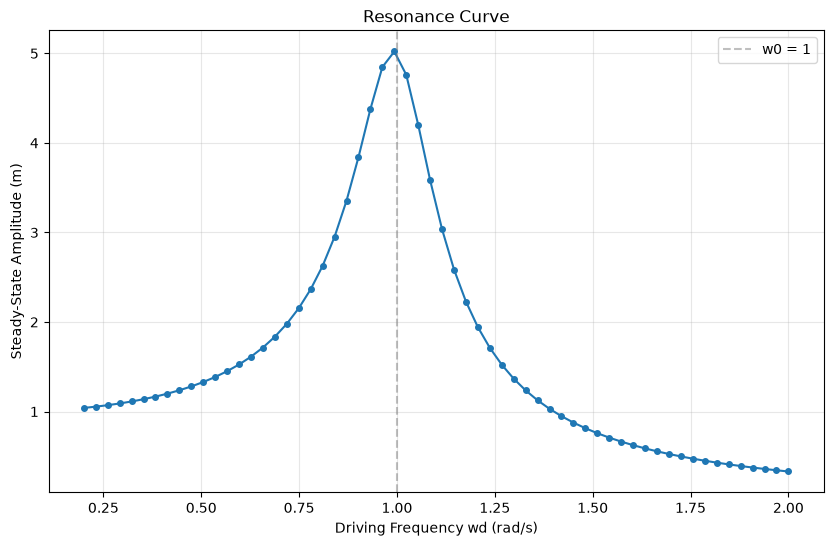

Peak amplitude at wd = 0.993
Natural frequency w0 = 1.000


In [11]:
omega_values = np.linspace(0.2, 2.0, 60)
amplitudes = []

for wd in omega_values:
    t_sweep, x_sweep = simulate_driven(wd, F0, b_drive, dt=0.01, t_max=150.0)
    n_start = int(0.8 * len(x_sweep))
    amp = np.max(np.abs(x_sweep[n_start:]))
    amplitudes.append(amp)

amplitudes = np.array(amplitudes)
peak_omega = omega_values[np.argmax(amplitudes)]

plt.figure(figsize=(10, 6))
plt.plot(omega_values, amplitudes, 'o-', markersize=4)
plt.axvline(omega0, color='gray', linestyle='--', alpha=0.5, label='w0 = 1')
plt.xlabel('Driving Frequency wd (rad/s)')
plt.ylabel('Steady-State Amplitude (m)')
plt.title('Resonance Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Peak amplitude at wd = {peak_omega:.3f}")
print(f"Natural frequency w0 = {omega0:.3f}")

**Interpretation:** The amplitude peaks at a driving frequency printed above that sits just under w0 = 1, which matches the theory; the exact peak location is slightly below w0 whenever there is damping and only equals w0 exactly in the undamped limit. The peak is there because that is where the spring restoring force and the driving force fall into step with each other cycle after cycle, so energy is brought in and building up amplitude instead of parts of the drive fighting the motion. If the damping were reduced, less energy would leak out per cycle, so the peak would grow taller and narrower, since it would take driving frequencies further from w0 before the drive falls out of step badly enough to lose much amplitude.

## Bonus: The Nonlinear Pendulum

The small-angle pendulum is just an SHO, but the real equation of motion uses sin(theta), not theta. We simulate it directly and see how the period depends on amplitude.

In [12]:
def simulate_pendulum(theta0_deg, dt=0.001, n_periods=5, g=9.81, L=1.0):
    omega0_pend = np.sqrt(g / L)
    T_small = 2 * np.pi / omega0_pend

    theta = np.radians(theta0_deg)
    omega_val = 0.0
    t = 0.0
    ts, thetas = [t], [theta]

    while t < n_periods * T_small:
        alpha = -(g / L) * np.sin(theta)
        omega_val = omega_val + alpha * dt
        theta = theta + omega_val * dt
        t = t + dt

        ts.append(t)
        thetas.append(theta)

    return np.array(ts), np.array(thetas)

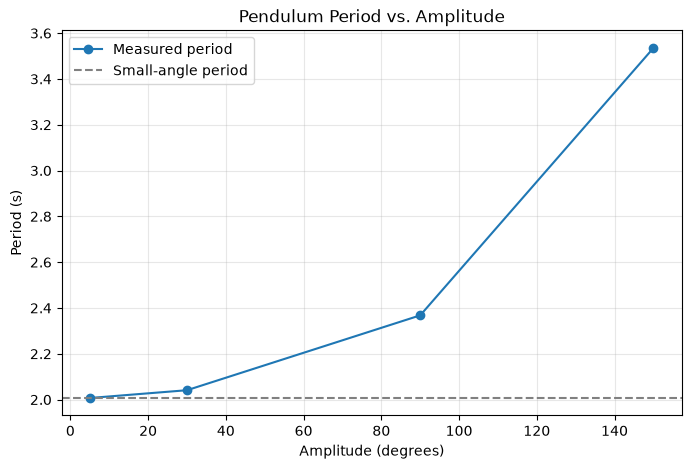

Amplitude 5 deg: period = 2.0070 s, +0.05 % vs small-angle value
Amplitude 30 deg: period = 2.0410 s, +1.74 % vs small-angle value
Amplitude 90 deg: period = 2.3678 s, +18.03 % vs small-angle value
Amplitude 150 deg: period = 3.5351 s, +76.22 % vs small-angle value


In [13]:
def measure_period(theta0_deg, dt=0.001):
    t_p, theta_p = simulate_pendulum(theta0_deg, dt=dt, n_periods=6)
    theta0_sign = np.sign(theta_p[1] - theta_p[0]) if theta_p[1] != theta_p[0] else 1
    crossings = []
    for i in range(1, len(theta_p)):
        if theta_p[i - 1] < 0 <= theta_p[i]:
            frac = -theta_p[i - 1] / (theta_p[i] - theta_p[i - 1])
            crossings.append(t_p[i - 1] + frac * dt)
    periods = np.diff(crossings)
    return np.mean(periods)

g, L = 9.81, 1.0
T_small_angle = 2 * np.pi * np.sqrt(L / g)

amplitudes_deg = [5, 30, 90, 150]
periods_measured = [measure_period(a) for a in amplitudes_deg]

plt.figure(figsize=(8, 5))
plt.plot(amplitudes_deg, periods_measured, 'o-', label='Measured period')
plt.axhline(T_small_angle, color='gray', linestyle='--', label='Small-angle period')
plt.xlabel('Amplitude (degrees)')
plt.ylabel('Period (s)')
plt.title('Pendulum Period vs. Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for a, p in zip(amplitudes_deg, periods_measured):
    pct = (p - T_small_angle) / T_small_angle * 100
    print(f"Amplitude {a} deg: period = {p:.4f} s, {pct:+.2f} % vs small-angle value")

At 5 degrees, the measured period lands right on the small-angle prediction, confirming the simulation is working before pushing it into the nonlinear regime. The period grows as amplitude increases, barely noticed at 30 degrees (under 2%), then off by 90 degrees and longer by 150 degrees, since sin(theta) falls further and further below theta itself as the swing gets larger, which means less restoring force than the linear formula assumes and a slower swing. The small-angle approximation stays reasonable out to 30 degrees or so, but by 90 degrees it is off by nearly 20%, which shows how quickly a linear approximation can stop being valid once the swings get large.